In [1]:
# import numpy for numerical operations
import numpy as np

# import pandas for data handling
import pandas as pd

# import a function to split the dataset
from sklearn.model_selection import train_test_split

# import matplotlib for data visualization
import matplotlib.pyplot as plt

# import seaborn for advanced statistical plots
import seaborn as sns

In [2]:
# load only the required columns from the CSV file
df = pd.read_csv('train.csv', usecols=['Age', 'Fare', 'Survived'])

In [3]:
# show the first 5 rows of the dataset
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
# calculate the percentage of missing values in each column
df.isnull().mean() * 100

,0
Survived,0.00000
Age,19.86532
Fare,0.00000


In [5]:
# separate the input features from the dataset
X = df.drop(columns=['Survived'])

# store the target column separately
y = df['Survived']

In [6]:
# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # keep 20% of the data for testing
    random_state=2      # get the same split every time
)

In [7]:
# display the training feature data
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [8]:
# create a copy of the Age column in the training data
X_train['Age_imputed'] = X_train['Age']

# create a copy of the Age column in the testing data
X_test['Age_imputed'] = X_test['Age']

In [9]:
# show the last 5 rows of the testing data
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [10]:
# fill missing values in Age_imputed with random Age values from the training data
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = (
    X_train['Age']
    .dropna()                                      # remove missing Age values
    .sample(X_train['Age'].isnull().sum())         # randomly select values
    .values                                        # convert to NumPy array
)

# fill missing values in the test data using random Age values from the training data
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = (
    X_train['Age']
    .dropna()                                     # remove missing Age values
    .sample(X_test['Age'].isnull().sum())         # randomly select values
    .values                                       # convert to NumPy array
)

/tmp/ipykernel_12675/890517812.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = (
/tmp/ipykernel_12675/890517812.py:10: FutureWarning: ChainedAssignmentError: behaviour will change

In [11]:
# remove missing Age values, randomly select the required number of values, and convert them to a NumPy array
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([39.  , 41.  , 27.  ,  8.  , 32.  , 61.  , 30.  , 28.  , 22.  ,
       48.  , 43.  , 16.  , 16.  , 35.  , 23.  , 20.  , 48.  , 27.  ,
        5.  , 50.  , 17.  , 22.  , 56.  , 20.  , 20.  , 22.  , 26.  ,
       30.  , 38.  , 23.  , 32.  , 19.  , 24.  , 20.  , 57.  ,  9.  ,
       60.  , 17.  , 24.  , 45.5 , 39.  , 56.  ,  2.  , 27.  , 45.  ,
       34.  , 34.  , 24.  , 11.  , 31.  , 22.  , 23.  ,  6.  , 20.  ,
       31.  , 17.  , 42.  , 61.  , 40.  , 37.  , 31.  , 47.  , 50.  ,
       58.  , 30.  , 19.  ,  3.  ,  8.  , 31.  ,  7.  , 27.  , 33.  ,
       29.  , 35.  ,  0.83, 24.  , 54.  , 33.  ,  7.  ,  4.  , 39.  ,
       14.  , 21.  , 15.  , 22.  , 22.  , 27.  , 17.  , 39.  , 19.  ,
       38.  , 16.  , 45.  ,  5.  ,  9.  , 41.  , 25.  , 28.  , 30.  ,
        4.  , 43.  , 36.  , 21.  , 34.  , 41.  , 50.  , 23.  , 28.  ,
       65.  , 16.  , 36.  , 47.  , 24.  , 28.5 , 28.5 , 45.  , 29.  ,
       27.  , 34.  , 58.  , 16.  , 42.  , 21.  , 24.  , 62.  , 32.  ,
       19.  , 34.  ,

In [12]:
# count the total number of missing values in the Age column
X_train['Age'].isnull().sum()

np.int64(148)

In [13]:
# display the training data
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,26.0
493,71.0,49.5042,71.0
527,NaN,221.7792,29.0


/tmp/ipykernel_12675/2734537171.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'], label='Original', hist=False)
/tmp/ipykernel_12675/2734537171.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age_imputed'], label='Imputed', hist=False)


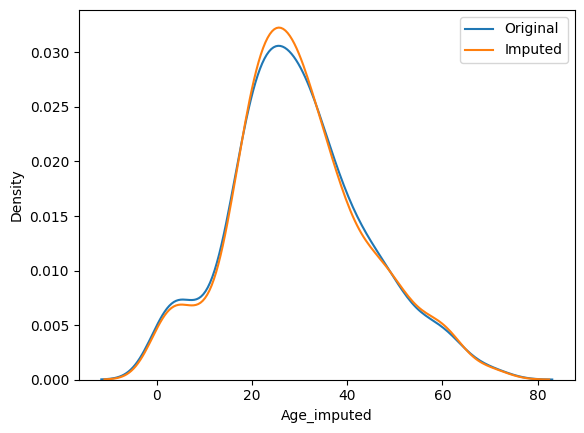

In [14]:
# plot the distribution of the original Age column
sns.distplot(X_train['Age'], label='Original', hist=False)

# plot the distribution of the imputed Age column
sns.distplot(X_train['Age_imputed'], label='Imputed', hist=False)

# display the legend
plt.legend()

# show the plot
plt.show()

In [15]:
# calculate and compare the variance of the original and imputed Age columns
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.3495133904614
Variance after random imputation:  200.70411623050327


In [16]:
# calculate the covariance between Fare, Age, and Age_imputed
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,66.338705
Age,71.512440,204.349513,204.349513
Age_imputed,66.338705,204.349513,200.704116


<Axes: >

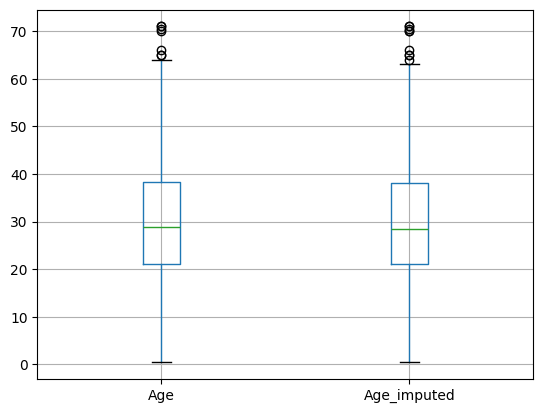

In [17]:
# compare the original and imputed Age columns using boxplots
X_train[['Age', 'Age_imputed']].boxplot()

Not much impact on Outliers

In [18]:
# load only the required columns from the CSV file
data = pd.read_csv(
    'house-train.csv',
    usecols=['GarageQual', 'FireplaceQu', 'SalePrice']
)

In [19]:
# show the first 5 rows of the dataset
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [20]:
# calculate the percentage of missing values in each column
data.isnull().mean() * 100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


In [21]:
# store the complete dataset as the input features
X = data

# store the target column separately
y = data['SalePrice']

In [22]:
# split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # keep 20% of the data for testing
    random_state=2      # get the same split every time
)

In [23]:
# create a copy of the GarageQual column in the training data
X_train['GarageQual_imputed'] = X_train['GarageQual']

# create a copy of the GarageQual column in the testing data
X_test['GarageQual_imputed'] = X_test['GarageQual']

# create a copy of the FireplaceQu column in the training data
X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']

# create a copy of the FireplaceQu column in the testing data
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [24]:
# display 5 random rows from the training dataset
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
676,NaN,Fa,87000,Fa,NaN
1225,NaN,TA,145000,TA,NaN
414,TA,TA,228000,TA,TA
390,NaN,TA,119000,TA,NaN
1169,TA,TA,625000,TA,TA


In [25]:
# fill missing GarageQual values in the training data with random existing values
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = (
    X_train['GarageQual']
    .dropna()                                               # remove missing values
    .sample(X_train['GarageQual'].isnull().sum())           # randomly select values
    .values                                                 # convert to NumPy array
)

# fill missing GarageQual values in the testing data using training data
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = (
    X_train['GarageQual']
    .dropna()                                              # remove missing values
    .sample(X_test['GarageQual'].isnull().sum())           # randomly select values
    .values                                                # convert to NumPy array
)

# fill missing FireplaceQu values in the training data with random existing values
X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = (
    X_train['FireplaceQu']
    .dropna()                                                 # remove missing values
    .sample(X_train['FireplaceQu'].isnull().sum())            # randomly select values
    .values                                                   # convert to NumPy array
)

# fill missing FireplaceQu values in the testing data using training data
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = (
    X_train['FireplaceQu']
    .dropna()                                                # remove missing values
    .sample(X_test['FireplaceQu'].isnull().sum())            # randomly select values
    .values                                                  # convert to NumPy array
)

/tmp/ipykernel_12675/3866769358.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = (
/tmp/ipykernel_12675/3866769358.py:2: SettingWithCopyWarning: 
A value is trying to

## **Original vs Imputed --- Category Frequency**

In [26]:
# compare the category proportions before and after random sample imputation
temp = pd.concat(
    [
        # calculate the proportion of each category in the original data
        X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),

        # calculate the proportion of each category after imputation
        X_train['GarageQual_imputed'].value_counts() / len(X_train)
    ],
    axis=1
)

# rename the columns
temp.columns = ['original', 'imputed']

In [27]:
# display the comparison table
temp

,original,imputed
TA,0.951043,0.952055
Fa,0.037171,0.036815
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [28]:
# compare the category proportions before and after random sample imputation
temp = pd.concat(
    [
        # calculate the proportion of each category in the original data
        X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),

        # calculate the proportion of each category after imputation
        X_train['FireplaceQu_imputed'].value_counts() / len(X_train)
    ],
    axis=1
)

# rename the columns
temp.columns = ['original', 'imputed']

# display the comparison table
temp

,original,imputed
Gd,0.494272,0.494007
TA,0.412439,0.413527
Fa,0.040917,0.039384
Po,0.027823,0.028253
Ex,0.024550,0.024829


/tmp/ipykernel_12675/2898034811.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(
/tmp/ipykernel_12675/2898034811.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(
/tmp/ipykernel_12675/2898034811.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed

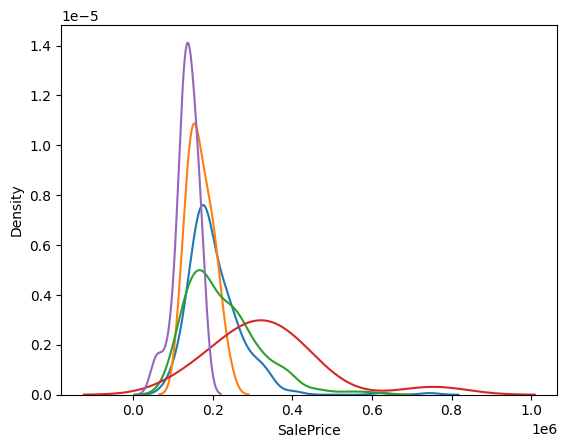

In [29]:
# plot the SalePrice distribution for each FireplaceQu category
for category in X_train['FireplaceQu'].dropna().unique():

    # select SalePrice values for the current category and plot the density curve
    sns.distplot(
        X_train[X_train['FireplaceQu'] == category]['SalePrice'],
        hist=False,
        label=category
    )

# display the plot
plt.show()

/tmp/ipykernel_12675/2389443012.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(
/tmp/ipykernel_12675/2389443012.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(
/tmp/ipykernel_12675/2389443012.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed

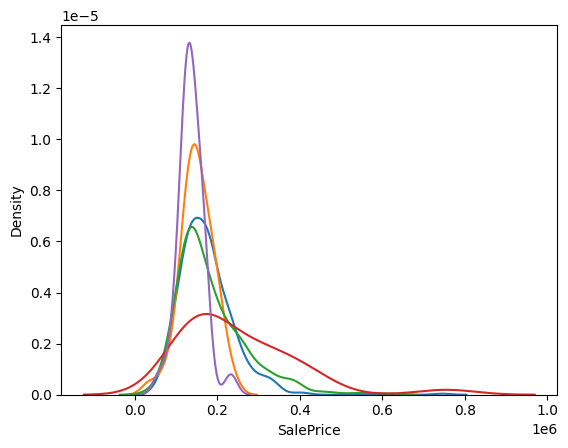

In [30]:
# plot the SalePrice distribution for each imputed FireplaceQu category
for category in X_train['FireplaceQu_imputed'].dropna().unique():

    # select SalePrice values for the current imputed category and plot the density curve
    sns.distplot(
        X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],
        hist=False,
        label=category
    )

# display the plot
plt.show()